In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
data20 = processed_data_20cm
data30 = processed_data_30cm

In [14]:
def wilcoxon_signed_rank_test_20cm(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = {}
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data20[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            # Detect peaks
            peak_idx_P0 = find_peaks(eta_P0, height=(0.9*np.sqrt(2)*np.nanstd(eta_P0), 1.2*np.sqrt(2)*np.nanstd(eta_P0)), distance=90)[0]
            peak_idx_P3 = find_peaks(eta_P3, height=(0.9*np.sqrt(2)*np.nanstd(eta_P3), 1.2*np.sqrt(2)*np.nanstd(eta_P3)), distance=90)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]
            n = len(amp_P0)

            amp_diff = np.round(amp_P0 - amp_P3, decimals=4)
            stat, p_value = stats.wilcoxon(amp_diff, alternative="greater")

            # Store results in a dataframe for later analysis
            results[(freq, v, cond, r)] = {
                'statistic': stat,
                'p_value': p_value,
                'n': n
            }      

        df = pd.DataFrame.from_dict(results, orient='index')
    return df

In [15]:
def wilcoxon_signed_rank_test_30cm(freq, cond):
    if freq == 0.898:
        volts = [0.149, 0.299, 0.453]
    if freq == 0.980:
        volts = [0.149, 0.295, 0.443]
    if freq == 1.061:
        volts = [0.149, 0.295, 0.449]
    if freq == 1.143:
        volts = [0.148, 0.295, 0.443]
    if freq == 1.225:
        volts = [0.152, 0.299, 0.471]
    if freq == 1.306:
        volts = [0.152, 0.302, 0.372, 0.461]
    if freq == 1.388:
        volts = [0.147, 0.285, 0.378, 0.468]
    if freq == 1.470:
        volts = [0.147, 0.296, 0.382, 0.459]

    results = {}
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data30[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            # Detect peaks
            peak_idx_P0 = find_peaks(eta_P0, height=(0.9*np.sqrt(2)*np.nanstd(eta_P0), 1.2*np.sqrt(2)*np.nanstd(eta_P0)), distance=100)[0]
            peak_idx_P3 = find_peaks(eta_P3, height=(0.9*np.sqrt(2)*np.nanstd(eta_P3), 1.2*np.sqrt(2)*np.nanstd(eta_P3)), distance=100)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]
            n = len(amp_P0)

            amp_diff = np.round(amp_P0 - amp_P3, decimals=4)
            stat, p_value = stats.wilcoxon(amp_diff, alternative="greater")

            # Store results in a dataframe for later analysis
            results[(freq, v, cond, r)] = {
                'statistic': stat,
                'p_value': p_value,
                'n': n
            }      

        df = pd.DataFrame.from_dict(results, orient='index')
    return df

In [16]:
f11_wilcoxon = wilcoxon_signed_rank_test_20cm(1.1, 'p005')
f12_wilcoxon = wilcoxon_signed_rank_test_20cm(1.2, 'p005')
f13_wilcoxon = wilcoxon_signed_rank_test_20cm(1.3, 'p005')
f14_wilcoxon = wilcoxon_signed_rank_test_20cm(1.4, 'p005')
f15_wilcoxon = wilcoxon_signed_rank_test_20cm(1.5, 'p005')
f16_wilcoxon = wilcoxon_signed_rank_test_20cm(1.6, 'p005')
f17_wilcoxon = wilcoxon_signed_rank_test_20cm(1.7, 'p005')
f18_wilcoxon = wilcoxon_signed_rank_test_20cm(1.8, 'p005')

f11_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.1, cond="None")
f12_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.2, cond="None")
f13_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.3, cond="None")
f14_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.4, cond="None")
f15_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.5, cond="None")
f16_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.6, cond="None")
f17_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.7, cond="None")
f18_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.8, cond="None")

In [17]:
f0898_wilcoxon = wilcoxon_signed_rank_test_30cm(0.898, 'p005')
f0980_wilcoxon = wilcoxon_signed_rank_test_30cm(0.980, 'p005')
f1061_wilcoxon = wilcoxon_signed_rank_test_30cm(1.061, 'p005')
f1143_wilcoxon = wilcoxon_signed_rank_test_30cm(1.143, 'p005')
f1225_wilcoxon = wilcoxon_signed_rank_test_30cm(1.225, 'p005')
f1306_wilcoxon = wilcoxon_signed_rank_test_30cm(1.306, 'p005')
f1388_wilcoxon = wilcoxon_signed_rank_test_30cm(1.388, 'p005')
f1470_wilcoxon = wilcoxon_signed_rank_test_30cm(1.470, 'p005')

f0898_wilcoxon_no = wilcoxon_signed_rank_test_30cm(0.898, cond="None")
f0980_wilcoxon_no = wilcoxon_signed_rank_test_30cm(0.980, cond="None")
f1061_wilcoxon_no = wilcoxon_signed_rank_test_30cm(1.061, cond="None")
f1143_wilcoxon_no = wilcoxon_signed_rank_test_30cm(1.143, cond="None")
f1225_wilcoxon_no = wilcoxon_signed_rank_test_30cm(1.225, cond="None")
f1306_wilcoxon_no = wilcoxon_signed_rank_test_30cm(1.306, cond="None")
f1388_wilcoxon_no = wilcoxon_signed_rank_test_30cm(1.388, cond="None")
f1470_wilcoxon_no = wilcoxon_signed_rank_test_30cm(1.470, cond="None")

In [18]:
# Concatenate all results into one dataframe
wilcoxon_20_plates = pd.concat([f11_wilcoxon, f12_wilcoxon, f13_wilcoxon, f14_wilcoxon, f15_wilcoxon, f16_wilcoxon, f17_wilcoxon, f18_wilcoxon])
wilcoxon_30_plates = pd.concat([f0898_wilcoxon, f0980_wilcoxon, f1061_wilcoxon, f1143_wilcoxon, f1225_wilcoxon, f1306_wilcoxon, f1388_wilcoxon, f1470_wilcoxon])
    
wilcoxon_20_no = pd.concat([f11_wilcoxon_no, f12_wilcoxon_no, f13_wilcoxon_no, f14_wilcoxon_no, f15_wilcoxon_no, f16_wilcoxon_no, f17_wilcoxon_no, f18_wilcoxon_no])
wilcoxon_30_no = pd.concat([f0898_wilcoxon_no, f0980_wilcoxon_no, f1061_wilcoxon_no, f1143_wilcoxon_no, f1225_wilcoxon_no, f1306_wilcoxon_no, f1388_wilcoxon_no, f1470_wilcoxon_no])

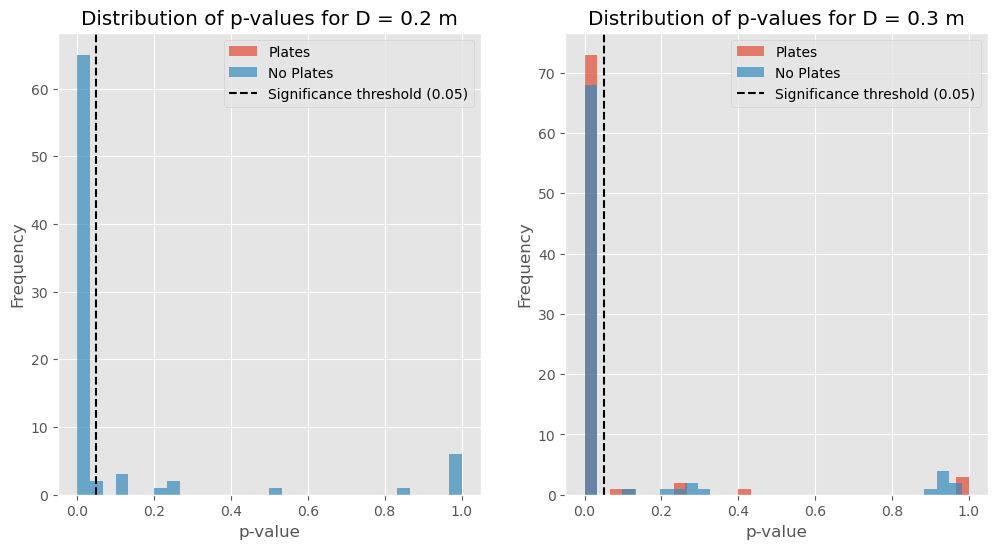

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].hist(wilcoxon_20_plates['p_value'], bins=30, alpha=0.7, label='Plates')
ax[0].hist(wilcoxon_20_no['p_value'], bins=30, alpha=0.7, label='No Plates')
ax[0].set_xlabel('p-value')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of p-values for D = 0.2 m')
ax[0].axvline(x=0.05, color='black', linestyle='--', label='Significance threshold (0.05)')
ax[0].legend()

ax[1].hist(wilcoxon_30_plates['p_value'], bins=30, alpha=0.7, label='Plates')
ax[1].hist(wilcoxon_30_no['p_value'], bins=30, alpha=0.7, label='No Plates')
ax[1].set_xlabel('p-value')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Distribution of p-values for D = 0.3 m')  
ax[1].axvline(x=0.05, color='black', linestyle='--', label='Significance threshold (0.05)')
ax[1].legend()

In [20]:
# Find cases of unsignificant results (p > 0.05) in the plates condition
insignificant_cases_20 = wilcoxon_20_plates[wilcoxon_20_plates['p_value'] > 0.05]
insignificant_cases_30 = wilcoxon_30_plates[wilcoxon_30_plates['p_value'] > 0.05]

print("Cases with p-value > 0.05 in plates condition:")
print(insignificant_cases_20)
print(insignificant_cases_30)

Cases with p-value > 0.05 in plates condition:
Empty DataFrame
Columns: [statistic, p_value, n]
Index: []
                     statistic   p_value   n
0.980 0.295 p005 R1        9.0  0.406250   5
                 R2       12.5  0.125000   5
                 R3       13.5  0.093750   5
1.225 0.299 p005 R1       61.0  0.971314  22
                 R2        2.5  0.999974  22
                 R3        6.0  0.999959  22
1.470 0.459 p005 R1        3.0  0.250000   2
                 R3        3.0  0.250000   2


In [21]:
# Find cases of unsignificant results (p > 0.05) in the no plates condition
insignificant_cases_no_20 = wilcoxon_20_no[wilcoxon_20_no['p_value'] > 0.05]
insignificant_cases_no_30 = wilcoxon_30_no[wilcoxon_30_no['p_value'] > 0.05]

print("Cases with p-value > 0.05 in no plates condition:")
print(insignificant_cases_no_20)
print(insignificant_cases_no_30)

Cases with p-value > 0.05 in no plates condition:
                  statistic   p_value   n
1.2 0.30 None R1       59.0  0.522747  16
              R2       48.0  0.850040  16
              R3       26.0  0.973743  16
1.5 0.20 None R1       40.0  1.000000  41
              R2        0.0  1.000000  41
              R3        3.0  1.000000  41
    0.30 None R3      266.0  0.974127  41
1.6 0.30 None R2        6.0  0.125000   3
1.7 0.30 None R1      867.5  0.206605  56
              R3      321.5  0.991699  48
1.8 0.10 None R1      815.0  0.264873  56
    0.25 None R2        6.0  0.125000   3
    0.30 None R1        3.0  0.250000   2
              R2        6.0  0.125000   3
              R3       10.0  0.062500   4
                     statistic   p_value   n
0.898 0.149 None R1       34.5  0.268555  10
                 R2       30.5  0.203125  10
                 R3       35.0  0.254883  10
      0.299 None R1        8.5  0.978516  10
                 R2        7.0  0.945312  10
        